In [32]:
CREATE_CSV_FILES = True

In [2]:
TRAIN_CSV_FILE = "train.csv"
TEST_CSV_FILE = "test.csv"

In [34]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import _cm
import librosa
import csv
import os

def extractWavFeatures(soundFilesFolder, csvFilename):
    header = 'filename rmse spectral_centroid spectral_bandwidth zero_crossing_rate' # label of extracted feature in csv
    for i in range(1, 21):
        header += f' mfcc{i}'
    header = header.split()
    print('CSV Header: ', header)
    file = open(csvFilename, 'w', newline='')
    writer = csv.writer(file) #to write data in csv
    writer.writerow(header)
    for filename in os.listdir(soundFilesFolder):
        number = f'{soundFilesFolder}/{filename}'
        y, sr = librosa.load(number, mono=True)
        y, index = librosa.effects.trim(y)
        rmse = librosa.feature.rms(y=y)
        spec_cent = librosa.feature.spectral_centroid(y=y, sr=sr)
        spec_bw = librosa.feature.spectral_bandwidth(y=y, sr=sr)
        zcr = librosa.feature.zero_crossing_rate(y)
        mfcc = librosa.feature.mfcc(y=y, sr=sr)
        to_append = f'{filename} {np.mean(rmse)} {np.mean(spec_cent)} {np.mean(spec_bw)} {np.mean(zcr)}'
        for e in mfcc:
            to_append += f' {np.mean(e)}'
        writer.writerow(to_append.split())
    
    file.close()

if (CREATE_CSV_FILES == True):
    extractWavFeatures("data/train", TRAIN_CSV_FILE)
    extractWavFeatures("data/test", TEST_CSV_FILE)
else:
    print("CSV files creation is skipped")
    


CSV Header:  ['filename', 'rmse', 'spectral_centroid', 'spectral_bandwidth', 'zero_crossing_rate', 'mfcc1', 'mfcc2', 'mfcc3', 'mfcc4', 'mfcc5', 'mfcc6', 'mfcc7', 'mfcc8', 'mfcc9', 'mfcc10', 'mfcc11', 'mfcc12', 'mfcc13', 'mfcc14', 'mfcc15', 'mfcc16', 'mfcc17', 'mfcc18', 'mfcc19', 'mfcc20']
CSV Header:  ['filename', 'rmse', 'spectral_centroid', 'spectral_bandwidth', 'zero_crossing_rate', 'mfcc1', 'mfcc2', 'mfcc3', 'mfcc4', 'mfcc5', 'mfcc6', 'mfcc7', 'mfcc8', 'mfcc9', 'mfcc10', 'mfcc11', 'mfcc12', 'mfcc13', 'mfcc14', 'mfcc15', 'mfcc16', 'mfcc17', 'mfcc18', 'mfcc19', 'mfcc20']


In [35]:
import pandas as pd
import csv
from sklearn import preprocessing

def preProcessData(csvFileName):
    data = pd.read_csv(csvFileName)
    filenameArray = data['filename']
    speakerArray = []
    for i in range(len(filenameArray)):
        speaker = "0"
        speakerArray.append(speaker)
    data['number'] = speakerArray

    data = data.drop(['filename'], axis=1)
    print(data.head())
    return data

trainData = preProcessData(TRAIN_CSV_FILE)
testData = preProcessData(TEST_CSV_FILE)

print(trainData)

       rmse  spectral_centroid  spectral_bandwidth  zero_crossing_rate  \
0  0.084662        1618.111898         2064.846379            0.059858   
1  0.126201        1352.913842         1951.914482            0.049931   
2  0.121898        1675.670111         1932.109531            0.088977   
3  0.072539        2365.903388         2238.296052            0.127411   
4  0.118728        1541.656324         1961.821521            0.063314   

        mfcc1       mfcc2      mfcc3      mfcc4      mfcc5      mfcc6  ...  \
0 -217.201309  126.457588  12.106718  17.929337  -7.933419  13.588254  ...   
1 -201.773407  134.614304  22.523781  31.559008  -2.655950  15.319532  ...   
2 -210.061813  108.051125  24.383257  53.079273  -0.843553  11.707172  ...   
3 -214.878357  107.804367  31.714722  17.761267 -23.993372  26.698536  ...   
4 -209.907272  126.519096  18.264681  22.736420  -4.981337   7.876415  ...   

      mfcc12     mfcc13    mfcc14    mfcc15     mfcc16    mfcc17    mfcc18  \
0   6.05

In [36]:
from sklearn.model_selection import train_test_split
X = np.array(trainData.iloc[:, :-1], dtype=float)
y = trainData.iloc[:, -1]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

X_test = np.array(testData.iloc[:, :-1], dtype=float)
y_test = testData.iloc[:, -1]

#randomize and extract the data from all rows and columns

In [37]:
#normalizing the dataset
from sklearn.preprocessing import StandardScaler, LabelEncoder
import numpy as np
scaler = StandardScaler()
X_train = scaler.fit_transform( X_train )
X_val=  scaler.transform( X_val )
X_test = scaler.transform( X_test )

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_val = label_encoder.transform(y_val)
y_test = label_encoder.transform(y_test)

In [38]:
from keras import models
from keras import layers
import keras

model = models.Sequential()
model.add(layers.Dense(256, activation='relu', input_shape=(X_train.shape[1],)))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

from keras.callbacks import EarlyStopping

es = EarlyStopping(monitor='val_loss', mode='min', verbose=1)

history = model.fit(X_train,
                    y_train,
                    validation_data=(X_val, y_val),
                    epochs=20,
                    batch_size=128,
                    callbacks=[es])

Epoch 1/20
1/1 [==============================] - 2s 2s/step - loss: 2.5238 - accuracy: 0.0000e+00 - val_loss: 2.6067 - val_accuracy: 0.0000e+00
Epoch 2/20
1/1 [==============================] - 0s 68ms/step - loss: 2.5545 - accuracy: 0.0000e+00 - val_loss: 2.4179 - val_accuracy: 0.0000e+00
Epoch 3/20
1/1 [==============================] - 0s 60ms/step - loss: 2.3284 - accuracy: 0.0000e+00 - val_loss: 2.2390 - val_accuracy: 0.0000e+00
Epoch 4/20
1/1 [==============================] - 0s 57ms/step - loss: 2.1908 - accuracy: 0.1429 - val_loss: 2.0549 - val_accuracy: 0.0000e+00
Epoch 5/20
1/1 [==============================] - 0s 58ms/step - loss: 1.8929 - accuracy: 0.2857 - val_loss: 1.8673 - val_accuracy: 0.6667
Epoch 6/20
1/1 [==============================] - 0s 56ms/step - loss: 1.8585 - accuracy: 0.2857 - val_loss: 1.6838 - val_accuracy: 1.0000
Epoch 7/20
1/1 [==============================] - 0s 68ms/step - loss: 1.5738 - accuracy: 0.7143 - val_loss: 1.5111 - val_accuracy: 1.0000
E

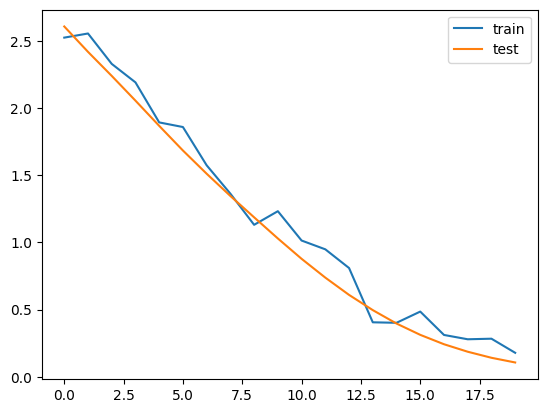

In [39]:
from matplotlib import pyplot
pyplot.plot(history.history['loss'], label='train')
pyplot.plot(history.history['val_loss'], label='test')
pyplot.legend()
pyplot.show()

In [43]:
def getSpeaker(speaker):
    speaker=str(speaker)
    if speaker == "0":
        return "Human"
    else:
        speaker = "AI"
    
def printPrediction(X_data, y_data, printDigit):
    for i in range(len(y_data)):
        prediction = getSpeaker(np.argmax(model.predict(X_data[i:i+1])[0]))
        speaker = getSpeaker(y_data[i])
        if printDigit == True:
            print("Number={0:d}, y={1:10s}- prediction= {2:10s}- match={3}".format(i, speaker, prediction, speaker==prediction))
        else:
            print("y={0:10s}- prediction={1:10s}- match={2}" .format(speaker, prediction, speaker==prediction))



In [44]:
import numpy as np
from keras import backend as K
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Convolution2D, MaxPooling2D
from keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

def report(X_data, y_data):
    y_pred = model.predict_classes(X_data)
    y_test_num = y_data.astype(np.int64)
    conf_mt = confusion_matrix(y_test_num, y_pred)
    print(conf_mt)
    plt.matshow(conf_mt)
    print('\nClassification Report')
    target_names = ["Human", 'AI']
    print(classification_report(y_test_num, y_pred))


In [45]:
print('\n# TEST DATA #\n')
score = model.evaluate(X_test, y_test)
print("%s: %.2f%%" % (model.metrics_names[1], score[1]*100))

printPrediction(X_test[0:10], y_test[0:4], True)


# TEST DATA #

1/1 [==============================] - 0s 79ms/step - loss: 0.0025 - accuracy: 1.0000
accuracy: 100.00%
1/1 [==============================] - 0s 63ms/step
Number=0, y=Human     - prediction= Human     - match=True
1/1 [==============================] - 0s 44ms/step
0
1/1 [==============================] - 0s 61ms/step
Number=1, y=Human     - prediction= Human     - match=True
1/1 [==============================] - 0s 39ms/step
0
1/1 [==============================] - 0s 43ms/step
Number=2, y=Human     - prediction= Human     - match=True
1/1 [==============================] - 0s 34ms/step
0
1/1 [==============================] - 0s 53ms/step
Number=3, y=Human     - prediction= Human     - match=True
1/1 [==============================] - 0s 75ms/step
0
